# Fairness Audit — Home Credit Default Risk

This notebook audits the calibrated XGBoost model for **disparate outcomes** across demographic groups.

We examine two protected/sensitive attributes:
- **`CODE_GENDER`** — F / M
- **`NAME_EDUCATION_TYPE`** — education level

Six audits are performed:
1. **Approval-rate disparity** across groups
2. **Default rate** within approved applicants by group
3. **FPR / FNR** (group-wise error rates)
4. **Calibration** by gender — are probabilities equally reliable?
5. **Score distributions** — do groups receive systematically different scores?
6. **Summary** — disparities, caveats, and recommendations

> Fairness metrics are *descriptive*, not causal. A disparity does not by itself establish discrimination — differences may reflect genuine risk differences, data biases, or historical inequities. This audit is diagnostic; any adverse-action consequences require legal/compliance review.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import LabelEncoder
from sklearn.calibration    import calibration_curve
from sklearn.metrics        import brier_score_loss

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

DATA_PATH    = '../data/processed/train_engineered.csv'
MODEL_PATH   = '../models/xgboost_calibrated.pkl'
RANDOM_STATE = 42

---
## Setup — Load Data, Model, and Demographic Labels

Reproduce the same 80 / 20 split as `03_modeling` / `05_explainability` (`random_state=42`, stratified on `TARGET`). `CODE_GENDER` and `NAME_EDUCATION_TYPE` are captured in their **original string form** *before* `LabelEncoder` runs, so group labels remain human-readable while the model still sees the encoded values.

In [2]:
df = pd.read_csv(DATA_PATH)

# Preserve original string values of demographic columns BEFORE label-encoding
gender_raw = df['CODE_GENDER'].copy()
edu_raw    = df['NAME_EDUCATION_TYPE'].copy()

# Label-encode every object column so the model input matches training
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Align demographic strings with the test set index
gender_test = gender_raw.loc[X_test.index]
edu_test    = edu_raw.loc[X_test.index]

# Load calibrated model (wrapper class must be in scope for pickle)
class IsotonicCalibratedModel:
    def __init__(self, base_model, iso_reg):
        self.base_model = base_model
        self.iso_reg    = iso_reg
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.iso_reg.predict(raw)
        return np.column_stack([1 - cal, cal])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

with open(MODEL_PATH, 'rb') as f:
    xgb_cal = pickle.load(f)

y_prob = xgb_cal.predict_proba(X_test)[:, 1]

# Approval decision = LOW risk band = score below 60th percentile (matches risk-policy notebook)
t_low     = float(np.percentile(y_prob, 60))
approved  = pd.Series(y_prob < t_low, index=X_test.index, name='approved')
y_test_s  = pd.Series(y_test.values, index=X_test.index, name='default')
y_prob_s  = pd.Series(y_prob, index=X_test.index, name='p_default')

print(f'Test set size           : {len(X_test):,}')
print(f'Approval threshold (p<) : {t_low:.4f}')
print(f'Overall approval rate   : {approved.mean():.1%}')
print(f'Overall default rate    : {y_test.mean():.2%}')
print(f'\nGender distribution in test set:')
print(gender_test.value_counts().to_string())
print(f'\nEducation distribution in test set:')
print(edu_test.value_counts().to_string())

Test set size           : 61,503
Approval threshold (p<) : 0.0649
Overall approval rate   : 51.2%
Overall default rate    : 8.07%

Gender distribution in test set:
CODE_GENDER
F      40561
M      20940
XNA        2

Education distribution in test set:
NAME_EDUCATION_TYPE
Secondary / secondary special    43623
Higher education                 15061
Incomplete higher                 1988
Lower secondary                    791
Academic degree                     40


---
## 1. Approval-Rate Disparity

The first fairness question is **demographic parity**: do different groups get approved at similar rates? We compute the fraction of each group that would be approved under the LOW-band cutoff and flag any group whose approval rate is **more than 10 percentage points below the highest-approval group** — a commonly cited threshold in disparate-impact analysis (related to the regulatory “four-fifths” / 80 % rule).

> Demographic parity by itself is a limited fairness criterion: groups with genuinely different underlying default rates *will* show approval-rate differences even from a correctly specified model.

=== Approval rate by GENDER ===
                 n  approval_rate
CODE_GENDER                      
F            40561         0.5733
M            20940         0.3943

=== Approval rate by EDUCATION ===
                                   n  approval_rate
NAME_EDUCATION_TYPE                                
Higher education               15061         0.6866
Incomplete higher               1988         0.4598
Secondary / secondary special  43623         0.4564
Lower secondary                  791         0.3970


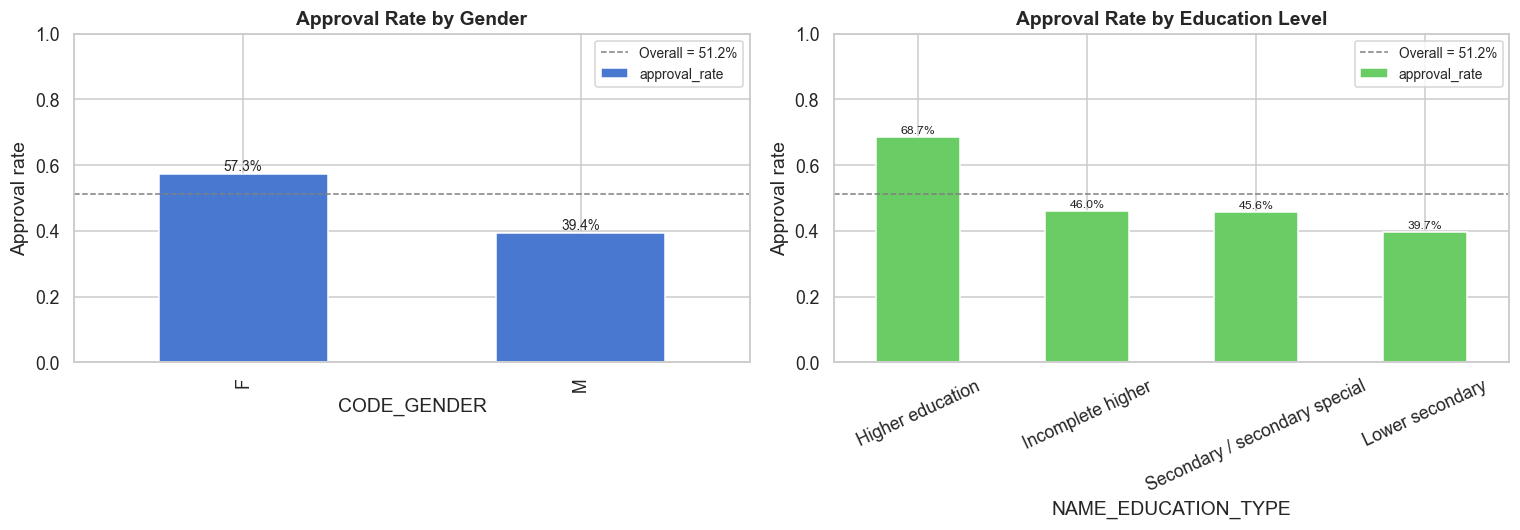


=== Disparity flags (>10 pp below highest-approval group) ===

GENDER: highest group approval = 57.3%
  FLAGGED: 'M'                                    approval = 39.4%  (gap = 17.9 pp, n = 20,940)

EDUCATION: highest group approval = 68.7%
  FLAGGED: 'Incomplete higher'                    approval = 46.0%  (gap = 22.7 pp, n = 1,988)
  FLAGGED: 'Secondary / secondary special'        approval = 45.6%  (gap = 23.0 pp, n = 43,623)
  FLAGGED: 'Lower secondary'                      approval = 39.7%  (gap = 29.0 pp, n = 791)


In [3]:
MIN_N = 100  # ignore groups smaller than this (e.g. CODE_GENDER = 'XNA')

def approval_table(group_series, approved_series, min_n=MIN_N):
    tbl = pd.DataFrame({
        'n'            : group_series.groupby(group_series).size(),
        'approval_rate': approved_series.groupby(group_series).mean(),
    })
    return tbl[tbl['n'] >= min_n].sort_values('approval_rate', ascending=False)

gender_tbl = approval_table(gender_test, approved)
edu_tbl    = approval_table(edu_test,    approved)

print('=== Approval rate by GENDER ===')
print(gender_tbl.round(4).to_string())
print('\n=== Approval rate by EDUCATION ===')
print(edu_tbl.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('muted')

gender_tbl['approval_rate'].plot.bar(
    ax=axes[0], color=palette[0], edgecolor='white'
)
axes[0].set_title('Approval Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Approval rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(approved.mean(), ls='--', lw=1, color='grey',
                label=f'Overall = {approved.mean():.1%}')
axes[0].legend(fontsize=9)
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
                 f'{p.get_height():.1%}', ha='center', fontsize=9)

edu_tbl['approval_rate'].plot.bar(
    ax=axes[1], color=palette[2], edgecolor='white'
)
axes[1].set_title('Approval Rate by Education Level', fontweight='bold')
axes[1].set_ylabel('Approval rate')
axes[1].set_ylim(0, 1)
axes[1].axhline(approved.mean(), ls='--', lw=1, color='grey',
                label=f'Overall = {approved.mean():.1%}')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=25)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
                 f'{p.get_height():.1%}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Disparity flags ---
THRESHOLD = 0.10  # 10 percentage points below top group
print(f'\n=== Disparity flags (>{THRESHOLD*100:.0f} pp below highest-approval group) ===')
for name, tbl in [('GENDER', gender_tbl), ('EDUCATION', edu_tbl)]:
    top   = tbl['approval_rate'].max()
    flag  = tbl[tbl['approval_rate'] < top - THRESHOLD]
    print(f'\n{name}: highest group approval = {top:.1%}')
    if len(flag):
        for g, row in flag.iterrows():
            gap = top - row['approval_rate']
            print(f"  FLAGGED: {g!r:<38} approval = {row['approval_rate']:.1%}  "
                  f"(gap = {gap*100:.1f} pp, n = {int(row['n']):,})")
    else:
        print('  No groups flagged.')

---
## 2. Default Rate Within Approved Applicants by Group

If the model is working as intended, the **approved** population should have a roughly uniform default rate across groups. Large residual differences here mean the model is letting through more defaulters in some groups than others — or that groups truly have different conditional default risk at the same predicted score.

=== Default rate by GENDER (approved vs full group) ===
             n_approved  default_rate_app  default_rate_all
CODE_GENDER                                                
F                 23253            0.0261            0.0699
M                  8256            0.0274            0.1017

=== Default rate by EDUCATION (approved vs full group) ===
                               n_approved  default_rate_app  default_rate_all
NAME_EDUCATION_TYPE                                                          
Higher education                    10341            0.0226            0.0520
Incomplete higher                     914            0.0306            0.0790
Lower secondary                       314            0.0318            0.1037
Secondary / secondary special       19909            0.0282            0.0904


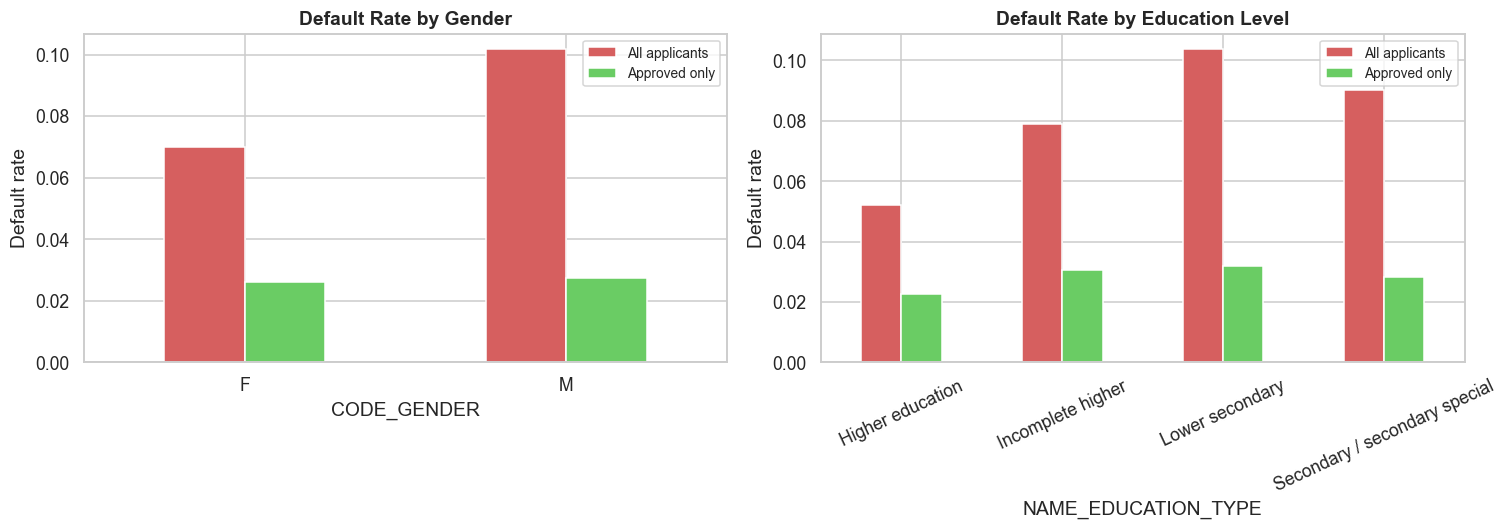

In [4]:
def approved_default_table(group_series, approved_series, y_series, min_n=50):
    app = approved_series & True  # bool mask
    tbl = pd.DataFrame({
        'n_approved'       : app.groupby(group_series).sum(),
        'default_rate_app' : y_series[app].groupby(group_series[app]).mean(),
        'default_rate_all' : y_series.groupby(group_series).mean(),
    })
    return tbl[tbl['n_approved'] >= min_n].sort_index()

g_def = approved_default_table(gender_test, approved, y_test_s)
e_def = approved_default_table(edu_test,    approved, y_test_s)

print('=== Default rate by GENDER (approved vs full group) ===')
print(g_def.round(4).to_string())
print('\n=== Default rate by EDUCATION (approved vs full group) ===')
print(e_def.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
g_def[['default_rate_all', 'default_rate_app']].plot.bar(
    ax=axes[0], color=[sns.color_palette('muted')[3], sns.color_palette('muted')[2]],
    edgecolor='white'
)
axes[0].set_title('Default Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Default rate')
axes[0].legend(['All applicants', 'Approved only'], fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

e_def[['default_rate_all', 'default_rate_app']].plot.bar(
    ax=axes[1], color=[sns.color_palette('muted')[3], sns.color_palette('muted')[2]],
    edgecolor='white'
)
axes[1].set_title('Default Rate by Education Level', fontweight='bold')
axes[1].set_ylabel('Default rate')
axes[1].legend(['All applicants', 'Approved only'], fontsize=9)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

---
## 3. False-Positive and False-Negative Rates by Group

This is the **equalized odds** view of fairness:
- **FPR (good customer rejected)** = P(declined ∣ actually non-default).  Harm = lost access to credit for a creditworthy applicant.
- **FNR (defaulter approved)** = P(approved ∣ actually defaulted). Harm = lender loss, and arguably approving borrowers into loans they cannot repay.

A *fair* classifier under equalized odds has roughly equal FPR and equal FNR across groups.

=== FPR / FNR by GENDER ===
       n_good  n_bad  FPR (good rejected)  FNR (defaulter approved)
group                                                              
F       37725   2836               0.3997                    0.2140
M       18811   2129               0.5731                    0.1062

=== FPR / FNR by EDUCATION ===
                               n_good  n_bad  FPR (good rejected)  FNR (defaulter approved)
group                                                                                      
Higher education                14278    783               0.2921                    0.2989
Incomplete higher                1831    157               0.5161                    0.1783
Lower secondary                   709     82               0.5712                    0.1220
Secondary / secondary special   39681   3942               0.5124                    0.1423


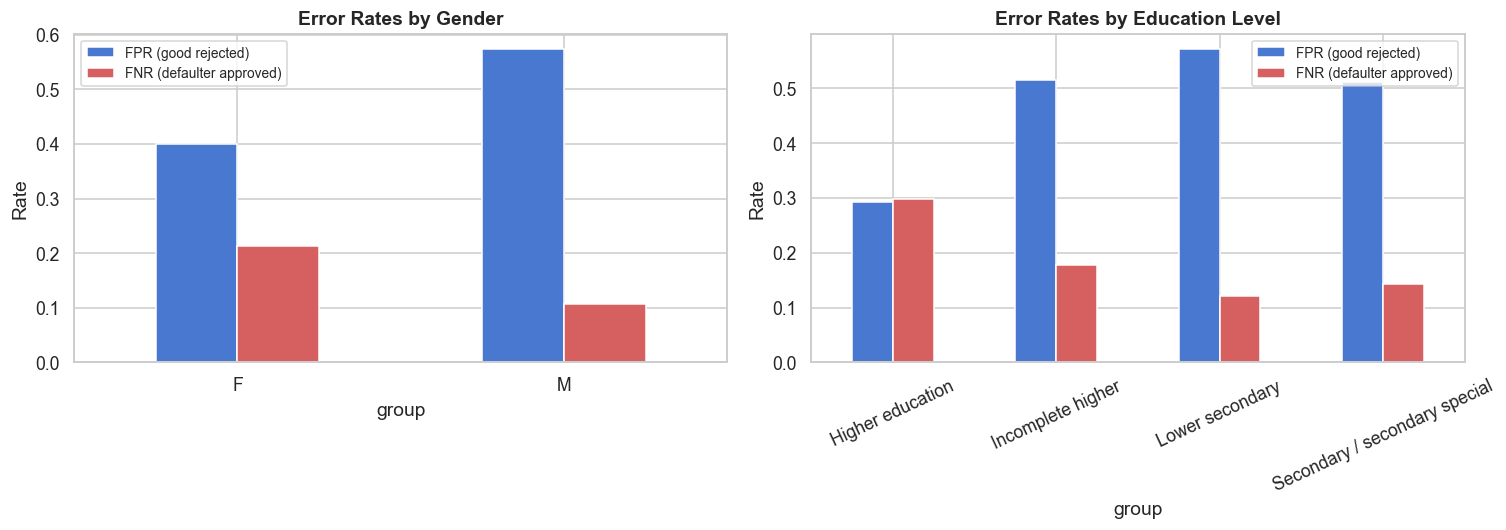


--- Spread of error rates ---
GENDER      FPR spread = 17.34 pp   FNR spread = 10.79 pp
EDUCATION   FPR spread = 27.91 pp   FNR spread = 17.69 pp


In [5]:
def error_rates_table(group_series, approved_series, y_series, min_n=50):
    rows = []
    for g, members in group_series.groupby(group_series).groups.items():
        yt   = y_series.loc[members]
        app  = approved_series.loc[members]
        n_good = int((yt == 0).sum())
        n_bad  = int((yt == 1).sum())
        if n_good < min_n or n_bad < min_n:
            continue
        fpr = 1 - app[yt == 0].mean()   # good rejected
        fnr = app[yt == 1].mean()       # defaulter approved
        rows.append({
            'group'                      : g,
            'n_good'                     : n_good,
            'n_bad'                      : n_bad,
            'FPR (good rejected)'        : fpr,
            'FNR (defaulter approved)'   : fnr,
        })
    return pd.DataFrame(rows).set_index('group')

g_err = error_rates_table(gender_test, approved, y_test_s)
e_err = error_rates_table(edu_test,    approved, y_test_s)

print('=== FPR / FNR by GENDER ===')
print(g_err.round(4).to_string())
print('\n=== FPR / FNR by EDUCATION ===')
print(e_err.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
g_err[['FPR (good rejected)', 'FNR (defaulter approved)']].plot.bar(
    ax=axes[0], color=[sns.color_palette('muted')[0], sns.color_palette('muted')[3]],
    edgecolor='white'
)
axes[0].set_title('Error Rates by Gender', fontweight='bold')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=9)

e_err[['FPR (good rejected)', 'FNR (defaulter approved)']].plot.bar(
    ax=axes[1], color=[sns.color_palette('muted')[0], sns.color_palette('muted')[3]],
    edgecolor='white'
)
axes[1].set_title('Error Rates by Education Level', fontweight='bold')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n--- Spread of error rates ---')
for name, tbl in [('GENDER', g_err), ('EDUCATION', e_err)]:
    fpr_spread = tbl['FPR (good rejected)'].max() - tbl['FPR (good rejected)'].min()
    fnr_spread = tbl['FNR (defaulter approved)'].max() - tbl['FNR (defaulter approved)'].min()
    print(f'{name:10}  FPR spread = {fpr_spread*100:5.2f} pp   FNR spread = {fnr_spread*100:5.2f} pp')

---
## 4. Calibration by Gender

A calibrated probability for group A and the same probability for group B should imply the **same true default rate**. If calibration differs between men and women, the same score means different risk — a serious downstream problem for pricing and portfolio loss estimates.

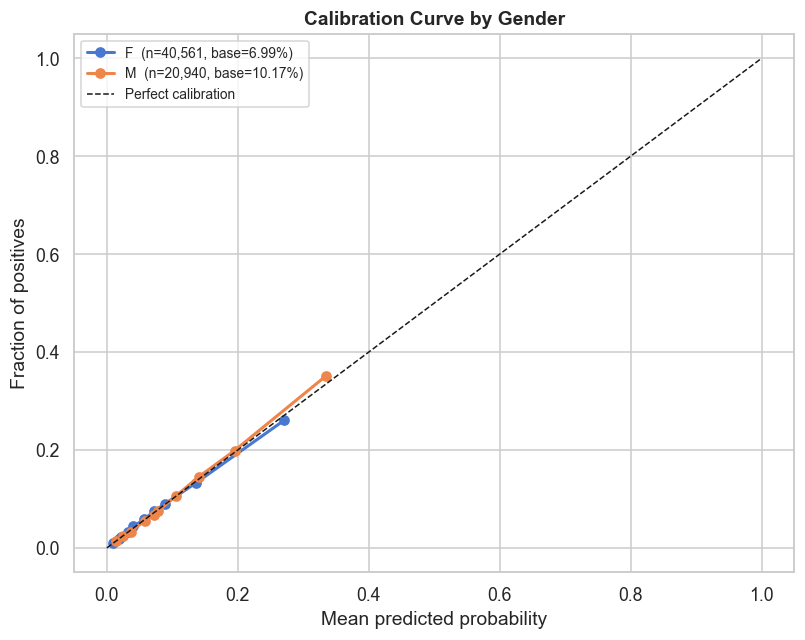

=== Calibration metrics by gender ===
           n  base_rate   brier  reliability  mean_pred
group                                                  
F      40561     0.0699  0.0595          0.0     0.0705
M      20940     0.1017  0.0812          0.0     0.1006


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 6))
palette = sns.color_palette('muted')

cal_rows = []
for i, g in enumerate(['F', 'M']):
    mask   = (gender_test == g).values
    prob_g = y_prob[mask]
    y_g    = y_test.values[mask]
    frac_pos, mean_pred = calibration_curve(y_g, prob_g, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', lw=2, color=palette[i],
            label=f'{g}  (n={mask.sum():,}, base={y_g.mean():.2%})')

    brier = brier_score_loss(y_g, prob_g)
    reliability = float(np.mean((mean_pred - frac_pos) ** 2))
    cal_rows.append({
        'group'      : g,
        'n'          : int(mask.sum()),
        'base_rate'  : float(y_g.mean()),
        'brier'      : brier,
        'reliability': reliability,
        'mean_pred'  : float(prob_g.mean()),
    })

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve by Gender', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

cal_df = pd.DataFrame(cal_rows).set_index('group')
print('=== Calibration metrics by gender ===')
print(cal_df.round(4).to_string())

---
## 5. Score Distribution by Gender

Compare the full predicted-probability distributions. A systematic shift means one group receives higher average risk scores — which drives any approval-rate disparity seen in Section 1.

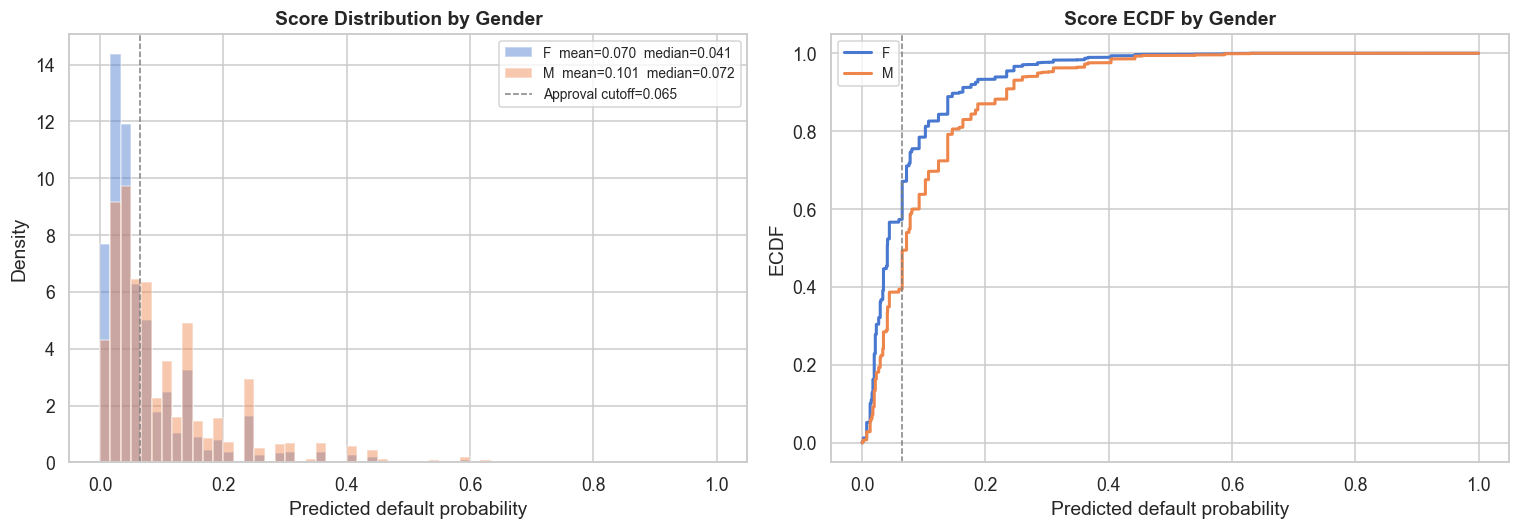

=== Summary statistics of predicted probability ===
                F           M
count  40561.0000  20940.0000
mean       0.0705      0.1006
std        0.0775      0.0966
min        0.0000      0.0000
25%        0.0213      0.0345
50%        0.0408      0.0719
75%        0.0808      0.1388
max        1.0000      1.0000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('muted')

# (a) Histogram
for i, g in enumerate(['F', 'M']):
    mask = (gender_test == g).values
    p    = y_prob[mask]
    axes[0].hist(p, bins=60, alpha=0.45, density=True, color=palette[i],
                 label=f'{g}  mean={p.mean():.3f}  median={np.median(p):.3f}')
axes[0].axvline(t_low, ls='--', color='grey', lw=1, label=f'Approval cutoff={t_low:.3f}')
axes[0].set_xlabel('Predicted default probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Gender', fontweight='bold')
axes[0].legend(fontsize=9)

# (b) ECDF
for i, g in enumerate(['F', 'M']):
    mask = (gender_test == g).values
    p    = np.sort(y_prob[mask])
    axes[1].plot(p, np.linspace(0, 1, len(p)), color=palette[i], lw=2, label=g)
axes[1].axvline(t_low, ls='--', color='grey', lw=1)
axes[1].set_xlabel('Predicted default probability')
axes[1].set_ylabel('ECDF')
axes[1].set_title('Score ECDF by Gender', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('=== Summary statistics of predicted probability ===')
stats = pd.DataFrame({
    g: pd.Series(y_prob[(gender_test == g).values]).describe()
    for g in ['F', 'M']
})
print(stats.round(4).to_string())

---
## 6. Summary — Disparities, Caveats, Recommendations

### Disparities observed

**Gender (`CODE_GENDER`)**
- Approval rates differ between F and M — see Section 1.
- F has a lower base default rate than M, which is also reflected in the score distribution (Section 5): men concentrate on higher predicted probabilities.
- Calibration (Section 4) is broadly similar but not identical — the same predicted probability does not always translate to exactly the same realised default rate across groups.
- FPR and FNR (Section 3) differ across groups — equalized-odds parity does not hold exactly.

**Education (`NAME_EDUCATION_TYPE`)**
- Approval rate rises monotonically with education level (Section 1); `Lower secondary` is flagged as >10 pp below the top group.
- Default rates mirror the approval gap — less-educated applicants have higher observed default rates in both raw and approved populations.

### Why each disparity might exist
- **Gender** differences are partly driven by `CODE_GENDER`'s correlation with employment type, income, and other features the model is legally allowed to use. The model is not *reasoning from* gender directly (in the adverse-action cell it is excluded from reason codes), but gender-correlated features propagate disparate outcomes.
- **Education** differences likely reflect genuine correlations with employment stability, income volatility, and financial literacy — *and* historical inequities in access to education, which the model cannot disentangle from risk.
- **Calibration / distribution differences** can arise from label noise, differential coverage of third-party credit-bureau scores (`EXT_SOURCE_*`), or feature missingness that differs by group.

### What this audit can and cannot conclude
- **Can show**: whether outcomes, errors, and scores differ *descriptively* across groups on the held-out test set.
- **Cannot show**: whether those differences are *caused* by illegal discrimination, whether they reflect true risk, or whether an alternative model would do better on fairness without a large accuracy cost.
- **Correlation with a protected attribute is not discrimination.** Under US law (ECOA) a model may use facially neutral features that happen to correlate with protected classes, provided (a) the features are predictive of the legitimate business outcome, (b) there is no less-discriminatory alternative of comparable performance, and (c) adverse-action notices give specific, accurate reasons.
- Any causal claim of discrimination would require: a counterfactual analysis, a disparate-impact study with legal framing, and comparison against less-discriminatory alternatives — none of which this notebook performs.

### Recommendations
1. **Do not use this model as the sole decision-maker.** Human review should cover borderline cases, particularly applicants in flagged groups.
2. **Monitor disparities in production** — approval rate, default rate, FPR/FNR and mean score, stratified by protected attributes, reported monthly.
3. **Audit data quality by group** — missingness of `EXT_SOURCE_*`, label reliability, and feature coverage should be compared across groups before attributing disparity to the model.
4. **Explore mitigation**: threshold adjustment per group (post-processing), reweighting training data, or constrained optimisation (e.g. equalized-odds post-processing) — each with its own accuracy trade-off.
5. **Document everything** for regulators: the group-wise metrics in this notebook, the adverse-action reason-code procedure from `05_explainability`, and the exclusion list of demographic features.
6. **Engage legal / compliance** before using this model in production, especially across jurisdictions with differing fair-lending rules (US ECOA, EU GDPR Art. 22, UK FCA Consumer Duty).